En el siguiente bloque de código importamos los directorios centralizados para todo el proyecto directamente desde `src/paths.py`como objetos de pathlib. La función `ensure_directories` crea las carpetas necesarias para el correcto funcionamiento del notebook.

In [1]:
from src.paths import RAW_PATH, REPORTS_DIR, ensure_directories

ensure_directories()

Se carga el archivo Parquet en un DataFrame de pandas. Si bien ahora se hará la verificación de nulos con missingno y el profiling estadístico se realizará con DuckDB directamente sobre el archivo en memoria, pandas es necesario río abajo para la validación con pandera.

In [2]:
import pandas as pd

paysim_df = pd.read_parquet(RAW_PATH)

# 1. verificación de nulos

Con missingno veremos la integridad de los datos en el archivo original, pues nos mostrará líneas blancas en la posición donde se encuentren nulos, en caso de encontrar deberíamos buscar un patrón o estructura a los valores faltantes.

<Axes: >

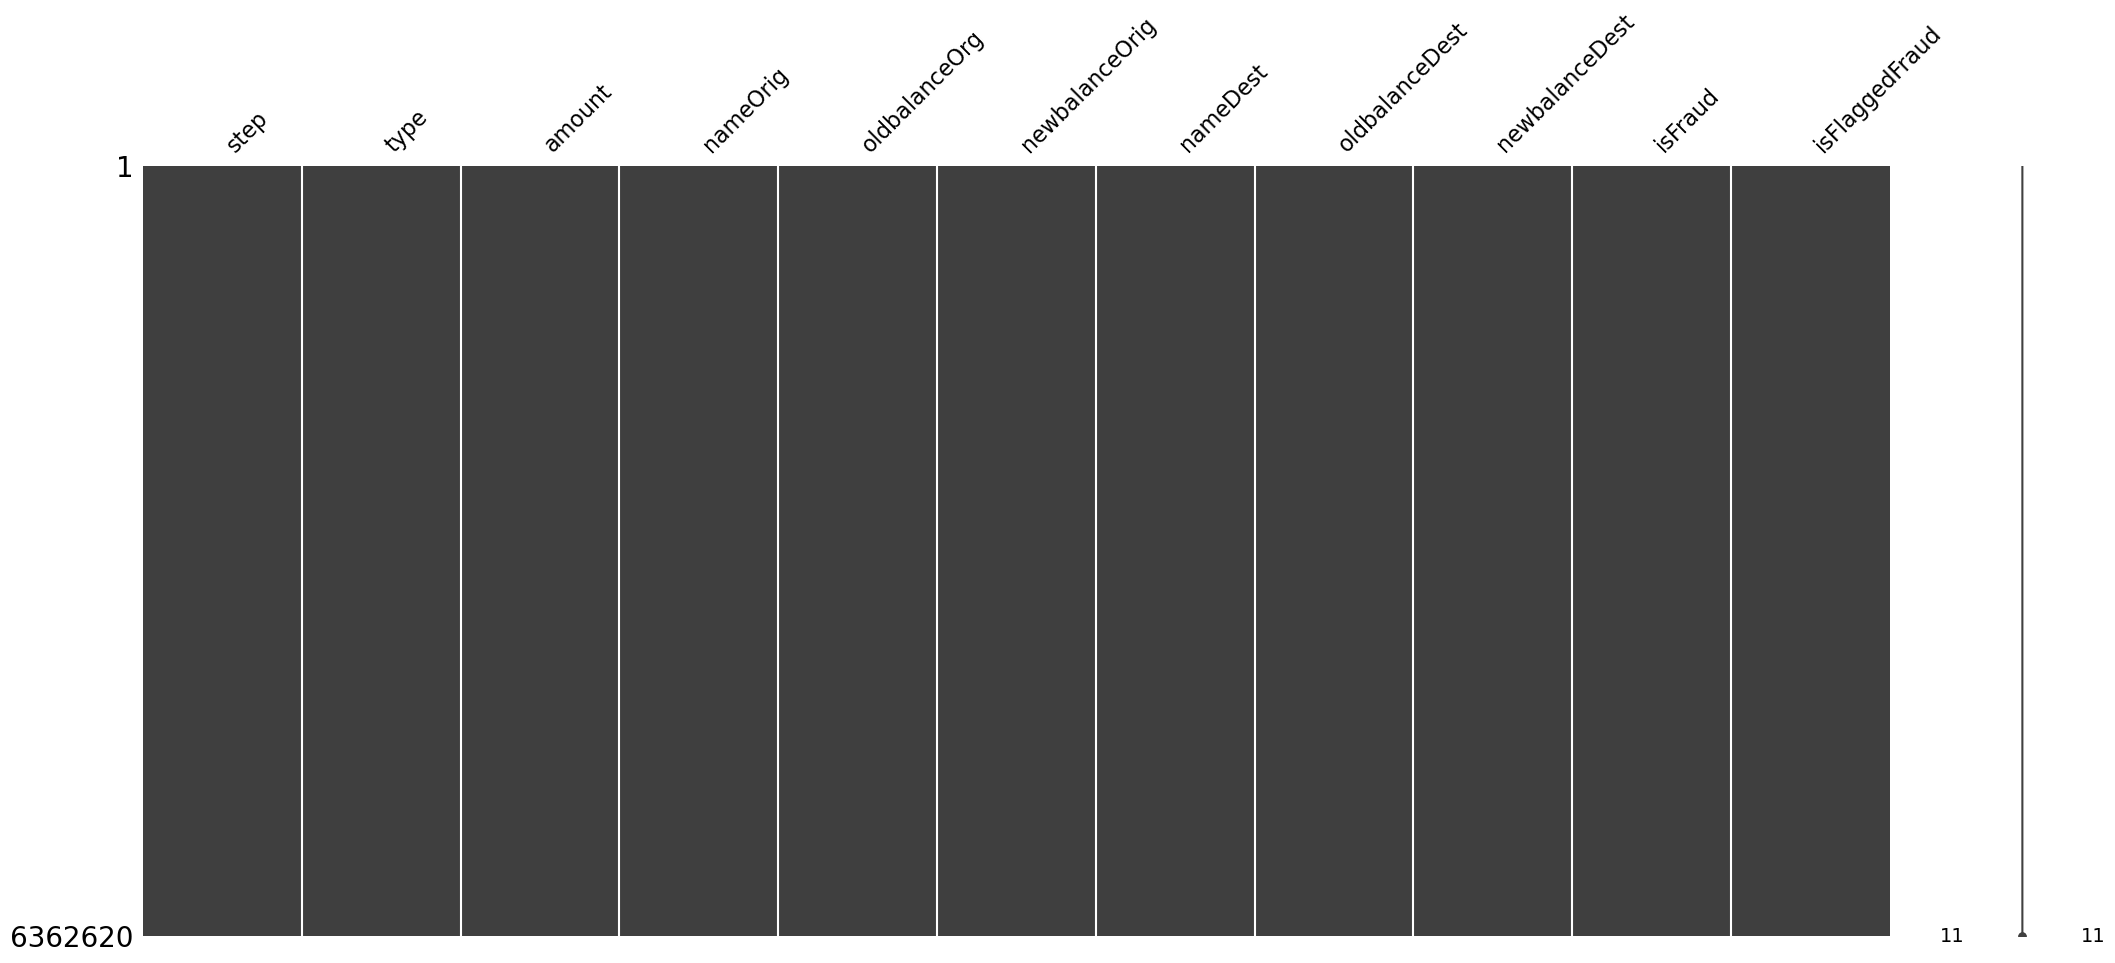

In [3]:
import missingno as msno

msno.matrix(paysim_df)

En este caso todas las columnas tienen su información íntegra, lo que significa que no necesitamos mucha más información de missingno.

# 2. Data profiling con DuckDB 

Con DuckDB haremos un profiling de los datos crudos e informar las decisiones que tomaremos para la operación de verificación río abajo.

`DESCRIBE` nos entrega el esquema del dataset: los nombres de las columnas, tipos de datos inferidos y la nulabilidad de cada una es lo que nos interesa.

In [4]:
import duckdb

con = duckdb.connect()

con.execute(f"""
    CREATE OR REPLACE VIEW raw_paysim AS
    SELECT * FROM read_parquet('{RAW_PATH}')
""")

schema = con.execute("DESCRIBE raw_paysim").df()

schema

,column_name,column_type,null,key,default,extra
0,step,BIGINT,YES,None,None,None
1,type,VARCHAR,YES,None,None,None
2,amount,DOUBLE,YES,None,None,None
3,nameOrig,VARCHAR,YES,None,None,None
4,oldbalanceOrg,DOUBLE,YES,None,None,None
5,newbalanceOrig,DOUBLE,YES,None,None,None
6,nameDest,VARCHAR,YES,None,None,None
7,oldbalanceDest,DOUBLE,YES,None,None,None
8,newbalanceDest,DOUBLE,YES,None,None,None
9,isFraud,BIGINT,YES,None,None,None


`SUMMARIZE` va más allá: calcula estadísticas de cada columna, lo que nos permite identificar anomalías, rangos inesperados, columnas con baja variabilidad. Esta operación es esencial para la toma de decisiones con pandera.

In [5]:
summary = con.execute("SUMMARIZE raw_paysim").df()

summary

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,step,BIGINT,1,743,879,243.39724563151657,142.33197104912838,155,242,337,6362620,0.0
1,type,VARCHAR,CASH_IN,TRANSFER,5,None,None,None,None,None,6362620,0.0
2,amount,DOUBLE,0.0,92445516.64,5076877,179861.90354913307,603858.231462939,13427.94833995754,75104.29199798683,208746.83217808636,6362620,0.0
3,nameOrig,VARCHAR,C1000000639,C999999784,6457872,None,None,None,None,None,6362620,0.0
4,oldbalanceOrg,DOUBLE,0.0,59585040.37,2158623,833883.1040744843,2888242.6730375267,0.0,14170.74182517857,110742.00798452274,6362620,0.0
5,newbalanceOrig,DOUBLE,0.0,49585040.37,2591251,855113.6685785875,2924048.5029542604,0.0,0.0,143563.27032503727,6362620,0.0
6,nameDest,VARCHAR,C1000004082,M999999784,2723511,None,None,None,None,None,6362620,0.0
7,oldbalanceDest,DOUBLE,0.0,356015889.35,2851509,1100701.66651967,3399180.1129944474,0.0,133129.51779540002,944149.6932289884,6362620,0.0
8,newbalanceDest,DOUBLE,0.0,356179278.92,2874326,1224996.3982019487,3674128.9421196226,0.0,215268.5792377321,1111582.3976993829,6362620,0.0
9,isFraud,BIGINT,0,1,2,0.001290820448180152,0.035904796801604154,0,0,0,6362620,0.0


`min`, `max` y `approx_unique` en el sumario nos marcan que `isFraud` junto a `isFlaggedFraud` tienen valores de booleanos, mas el tipo de dato de las columnas es `BIGINT`, por lo cual vamos a cambiarlo río abajo en una operación de transform.
la columna `step` va desde 1 a 743, estas son la cantidad de horas en un mes, lo que nos indica que sería prudente transformar esta columna a un formato más legible para hacer análisis temporales.
También confirmamos que todas las columnas tienen sus datos íntegros al observar `null_percentage`.

`type` es la variable categórica principal que documenta el tipo de transacción efectuada, ver la distribución de cada categoría en la columna nos dará información importante sobre la existencia de sesgos, lo que informará nuestras consultas de SQL.

In [6]:
type_dist = con.execute("""
    SELECT
        type,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
    FROM raw_paysim
    GROUP BY type
    ORDER BY count DESC
""").df()

type_dist

,type,n,porcentaje
0,CASH_OUT,2237500,35.17
1,PAYMENT,2151495,33.81
2,CASH_IN,1399284,21.99
3,TRANSFER,532909,8.38
4,DEBIT,41432,0.65


El sesgo es claro hacia las operaciones `CASH_OUT` y `PAYMENT`, ahora veamos si existe una relación entre estas operaciones y el fraude.

In [7]:
fraud_by_type = con.execute("""
    SELECT
        type,
        SUM(isFraud) AS fraud,
        COUNT(*) AS total,
        ROUND(AVG(isFraud) * 100, 4) AS pct_fraud
    FROM raw_paysim
    GROUP BY type
    ORDER BY pct_fraud DESC
""").df()

fraud_by_type

,type,n_fraud,n_total,pct_fraud
0,TRANSFER,4097.0,532909,0.7688
1,CASH_OUT,4116.0,2237500,0.1840
2,PAYMENT,0.0,2151495,0.0000
3,DEBIT,0.0,41432,0.0000
4,CASH_IN,0.0,1399284,0.0000


Acá vemos que sólo hay dos tipos de operaciones que concentran todas las transacciones fraudulentas y que la relación no es directamente proporcional con la distribución de operaciones: mientras `TRANSFER` es la 4ta operación más común es donde se concentra el mayor porcentaje de movimientos fraudulentos.

Es conocido que en este dataset el fraude opera mayoritariamente mediante cuentas mula, por lo que en la siguiente consulta confirmaremos el patrón discriminando las operaciones que concentran todos los fraudes que definimos con `fraud_by_type` y buscaremos las operaciones donde las columnas `oldbalanceDest` y `newbalanceDest` se mantienen en 0 a pesar de haber transado un monto mayor a 0, lo que es denominado una cuenta inerte.

In [8]:
dest_balance_inert = con.execute("""
    SELECT
        type,
        isFraud,
        COUNT(*) AS total,
        SUM(
            CASE
                WHEN oldbalanceDest = 0
                 AND newbalanceDest = 0
                 AND amount > 0
                THEN 1 ELSE 0
            END
        ) AS dest_inert,
        ROUND(
            SUM(
                CASE
                    WHEN oldbalanceDest = 0
                     AND newbalanceDest = 0
                     AND amount > 0
                    THEN 1 ELSE 0
                END
            ) * 100.0 / COUNT(*), 4
        ) AS pct_dest_inert
    FROM raw_paysim
    WHERE type IN ('TRANSFER', 'CASH_OUT')
    GROUP BY type, isFraud
    ORDER BY type, isFraud DESC
""").df() 

dest_balance_inert

,type,isFraud,n_total,n_dest_inert,pct_dest_inert
0,CASH_OUT,1,4116,2.0,0.0486
1,CASH_OUT,0,2233384,1600.0,0.0716
2,TRANSFER,1,4097,4068.0,99.2922
3,TRANSFER,0,528812,106.0,0.0200


La respuesta es clara: la operación `TRANSFER` concentra prácticamente todas las operaciones fraudulentas con patrón de cuenta mula, mas aun no tenemos un insight que nos indique cómo funcionan las operaciones fraudulentas con `CASH_OUT`, siendo que en `fraud_by_type`vimos que ambas operaciones prácticamente concentran la misma cantidad de operaciones fraudulentas podemos hipotetizar que pueden ser parte de un mismo modus operandi, por lo que en fase de consultas responderemos la pregunta: ¿existe una relación entre las cuentas mula fraudulentas con las operaciones `CASH_OUT` fraudulentas?

Ahora perfilaremos los outliers, calculando el IQR del dataset y sus límites y analizando los valores de las columnas que nos interesan.

In [9]:
columnas_numericas = summary[
    summary['column_type'].isin(['DOUBLE', 'BIGINT']) & 
    ~summary['column_name'].isin(['isFraud', 'isFlaggedFraud', 'step'])
]

def iqr_bounds(row, k=1.5):
    """
    Calcula el rango intercuartil y sus límites
    """
    try:
        q25, q75 = float(row.q25), float(row.q75)
        iqr = q75 - q25
        lower = max(float(row.min), q25 - k * iqr)
        upper = q75 + k * iqr
        return lower, upper
    except (TypeError, ValueError):
        return None, None
        
for row in columnas_numericas.itertuples(index=False):
    lower, upper = iqr_bounds(row)
    if lower is None:
        continue
    query = f"""
        SELECT COUNT(*) 
        FROM raw_paysim 
        WHERE {row.column_name} < {lower} OR {row.column_name} > {upper}
    """
    n_outliers = con.execute(query).fetchone()[0]
    
    if n_outliers > 0:
        print(
            f"{row.column_name:<15}:" 
            f"{n_outliers:>8} outliers en [{lower:.2f}, {upper:.2f}]"
        )

amount         :   338069 outliers en [0.00, 501725.16]
oldbalanceOrg  :  1100492 outliers en [0.00, 276855.02]
newbalanceOrig :  1055849 outliers en [0.00, 358908.18]
oldbalanceDest :   785242 outliers en [0.00, 2360374.23]
newbalanceDest :   738750 outliers en [0.00, 2778955.99]


El perfilado de outliers nos arroja cifras tremendamente altas, considerando que en las columnas `oldbalanceOrig` y `newbalanceOrig` más del 15% de las celdas se consideran outliers, mas esto no es un error, es un sesgo financiero conocido como heavy tailed distribution y será conservado en la próxima operación de transform.
Más allá de eso tenemos mucha información, vamos a graficar para poder tener mejores insights.

# 3. Graficación con matplotlib y seaborn

Vamos a confirmar la distribución de cola larga, por lo que graficaremos la columna `amount`con una distribución normal.

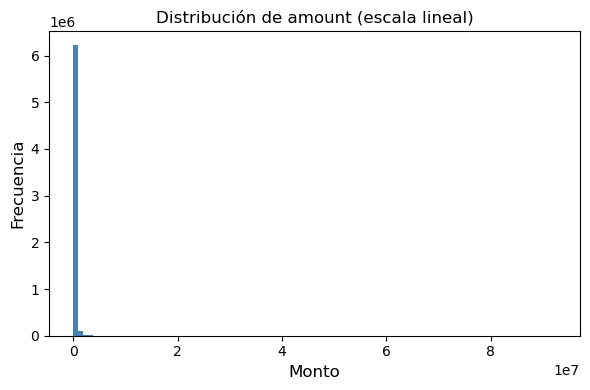

In [10]:
import matplotlib.pyplot as plt

amounts = con.execute("SELECT amount FROM raw_paysim").df()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(
    amounts["amount"], 
    bins=100, 
    color="steelblue"
)
ax.set_title("Distribución de amount (escala lineal)")
ax.set_xlabel("Monto", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "amount_distribution.png", dpi=150)
plt.show()

Este histograma no parece decirnos mucho, mas sí lo hace: nos muestra el increíble rango de cada monto transado en la columna `amount` (la transacción máxima es de más de $90,000,000), lo que comprime el espacio visual y además nos muestra que la mayoría de transacciones se ubican en montos bajos. 
Necesitaremos transformar este gráfico para poder sacar más información.

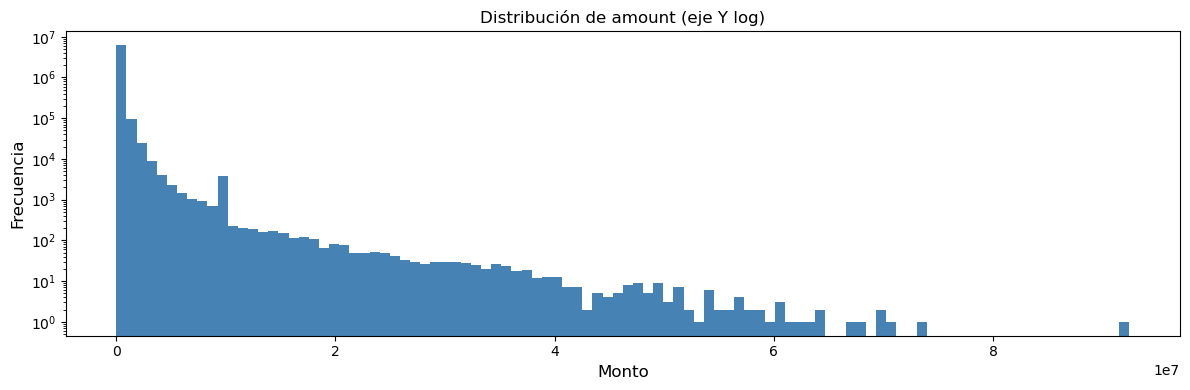

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(
    amounts["amount"], 
    bins=100, 
    color="steelblue", 
    log=True
)
ax.set_title("Distribución de amount (eje Y log)")      
ax.set_xlabel("Monto", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "amount_distribution_log.png", dpi=150)
plt.show()

Ya, ahora esto nos confirma la existencia del sesgo, además nos muestra algunas irregularidades en la distribución de ciertos montos en la forma de picos, lo que tendremos en cuenta al hacer consultas.

El boxplot nos permitirá comparar la distribución de los tipos de transacciones de forma simultánea y con el sesgo de cola larga controlado mediante escala logarítmica, esto nos dará información clave sobre: el comportamiento de los montos, la dispersión y medianas y el lugar de los outliers. 

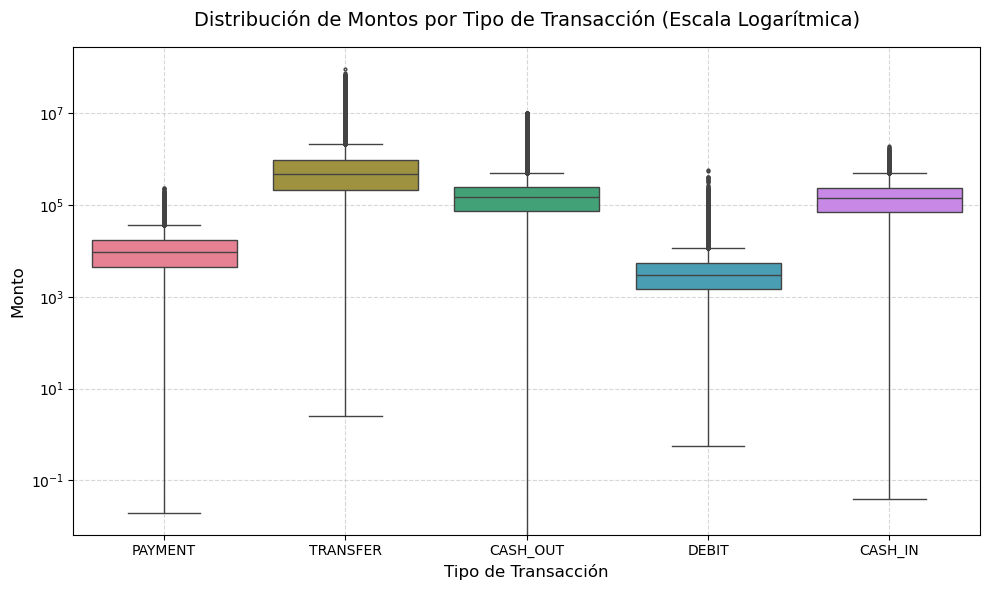

In [12]:
import seaborn as sns

query_boxplot = """
    SELECT type, amount 
    FROM raw_paysim 
    WHERE type IN ('TRANSFER', 'CASH_OUT', 'CASH_IN', 'PAYMENT', 'DEBIT')
"""
df_box = con.execute(query_boxplot).df()

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_box,
    x="type",
    y="amount",
    hue="type",
    palette="husl",
    ax=ax,
    fliersize=2 
)

ax.set_yscale("log")

ax.set_title(
    "Distribución de montos por tipo de transacción (Escala Logarítmica)", 
    fontsize=14, pad=15)
ax.set_xlabel("Tipo de Transacción", fontsize=12)
ax.set_ylabel("Monto", fontsize=12)
ax.grid(
    True, 
    which="both", 
    linestyle="--", 
    alpha=0.5
)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "amount_boxplot_by_type.png", dpi=150)
plt.show()

Acá vemos una confirmación de la necesidad de mantener los outliers: los montos más altos se concentran en las operaciones que estadísticamente operan de forma más fraudulenta.
`DEBIT` es el tipo de transacción con montos más bajos, su caja es la más baja de todos los tipos de operación.
Entendiendo el sesgo fraudulento hacia ciertos tipos de operaciones será fundamental hacer consultas que triangulen las cuentas que más operan con estas transacciones y observar sus comportamientos.


# 4. Validación con pandera

Ejecutaremos el script `validate` que se encuentra en `/src/validate.py` sobre el .parquet crudo, el data contract del script fue escrito tomando en cuenta el metaanálisis y perfilado de datos expuesto en este cuaderno. Mientras podría ser más riguroso y completo dada toda la información obtenida, no creemos que sea necesario, por lo que el validado crudo será "minimalista".

In [13]:
from src.validate import validate_raw

paysim_validado = validate_raw(paysim_df)

paysim_validado

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


Nuestro dataset pasó completo y sin errores: podemos entrar a transformar de forma segura.